<a href="https://colab.research.google.com/github/realclovisworld/Neural_Networks/blob/main/Task_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 7

**(QN)** Design and implement a CNN model to classify CIFAR10 image dataset. Use the concept of Data Augmentation while desiging the CNN model. Record the accuracy corresponding to the number of epochs.

**STEPS**


1. Import python liblaries for building and training the CNN
2. Load the CIFAR10 dataset into testing and training
3. Reshape the the image dta for the CNN model (batch_size,height,width,channels)
4. Perform Data type conversion and normalisation
5. Define the architecture of the Convolutional Neural Network (CNN)
6. Compile the model
7. Train the model
8. Evaluate the model on the test dataset
9. Generate predictions for the dataset and visualize







In [ ]:
#Import python liblaries

from __future__ import print_function
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
#Load the cifar10 dataset

(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1236s 7us/step


In [ ]:
#Print the shape of the dataset

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [ ]:
print(X_train.shape[0], 'train sample')
print(X_test.shape[0], 'test sample')

50000 train sample
10000 test sample


In [ ]:
#Data normalization
num_classes = 10

y_train = tf.keras.utils.to_categorical(Y_train, num_classes)
y_test =tf.keras.utils.to_categorical(Y_test, num_classes)
x_train = X_train.astype('float32')
x_test = X_test.astype('float32')
x_train /= 255
x_test /= 255


In [ ]:
#CNN model architecture

model = Sequential()

model.add(Conv2D(32, (3, 3), strides=(2,2), padding='same' , input_shape =  X_train.shape[1:]))
model.add(Activation('relu'))

model.add(Conv2D(32, (3, 3), strides = (2,2), padding='same'))
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation('relu'))


model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes))
model.add(Activation('softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,570 (2.13 MB)

 Trainable params: 558,570 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = tf.keras.optimizers.RMSprop(learning_rate=0.0001, decay=1e-6)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [ ]:
datagen = ImageDataGenerator( featurewise_center=False, samplewise_center=False, featurewise_std_normalization=False, zca_whitening = False,
rotation_range = 0, width_shift_range=0.1, height_shift_range =0.1, horizontal_flip = True, vertical_flip = False)

In [ ]:
datagen.fit(X_train)

In [ ]:
model.fit(datagen.flow(x_train, y_train, batch_size=32), epochs=10, validation_data=(x_test, y_test), shuffle=True )

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.2608 - loss: 2.0059 - val_accuracy: 0.3936 - val_loss: 1.7199
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.3619 - loss: 1.7415 - val_accuracy: 0.4464 - val_loss: 1.5553
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.4007 - loss: 1.6336 - val_accuracy: 0.4660 - val_loss: 1.4925
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.4235 - loss: 1.5772 - val_accuracy: 0.4769 - val_loss: 1.4367
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.4421 - loss: 1.5380 - val_accuracy: 0.4894 - val_loss: 1.3903
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.4554 - loss: 1.5000 - val_accuracy: 0.5101 - val_loss: 1.3594
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.4680 - loss: 1.4668 - val_accuracy: 0.5248 - val_loss: 1.3197
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.4797 -

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5544 - loss: 1.2381
Test loss: 1.2380940914154053
Test accuracy: 0.5544000267982483


In [ ]:
import numpy as np

# Make predictions on the test set
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Let's visualize some of the predictions.

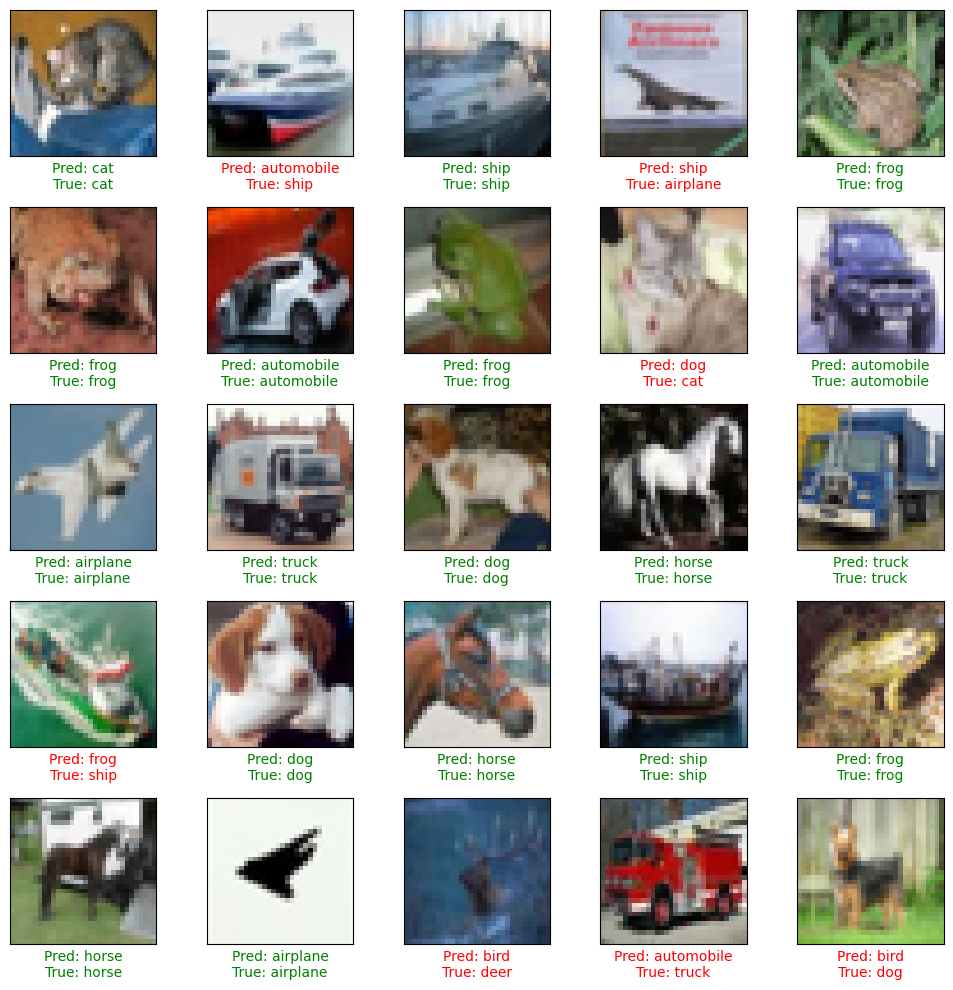

In [ ]:
# Define CIFAR-10 class names for better readability
cifar10_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Plotting some example predictions
plt.figure(figsize=(10, 10))
for i in range(25): # Display 25 images
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i]) # Display original image (not normalized)

    true_label_name = cifar10_class_names[true_classes[i]]
    predicted_label_name = cifar10_class_names[predicted_classes[i]]

    color = 'green' if predicted_classes[i] == true_classes[i] else 'red'
    plt.xlabel(f"Pred: {predicted_label_name}\nTrue: {true_label_name}", color=color)
plt.tight_layout()
plt.show()
